In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
df = pd.read_csv("finally.csv")

In [4]:

cols = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'AVG_ORDER_VALUE',
    'AVG_PURCHASE_GAP'
]

for col in cols:
    lower = df[col].quantile(0.25)   
    upper = df[col].quantile(0.75)   

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

df["PURCHASE_INTENSITY"] = np.sqrt(df["PURCHASE_INTENSITY"])

In [5]:

X = df[['TOTAL_SPENDING', 'FREQUENCY', 'Recency']]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

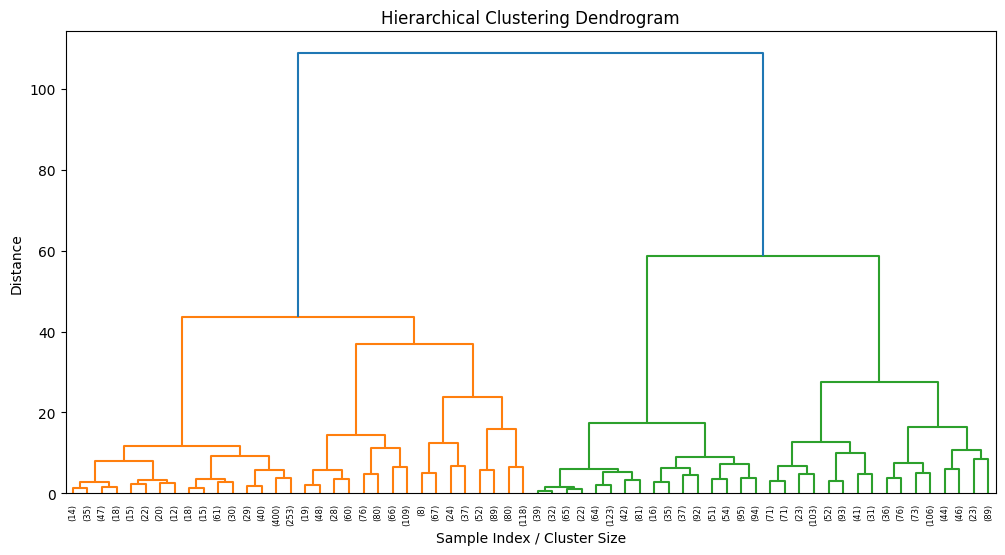

In [6]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index / Cluster Size')
plt.ylabel('Distance')
plt.show()

In [9]:

k = 4

hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
df['HC_Cluster'] = hc_labels

print(df['HC_Cluster'].value_counts())

HC_Cluster
3    1029
1     978
0     961
2     942
Name: count, dtype: int64


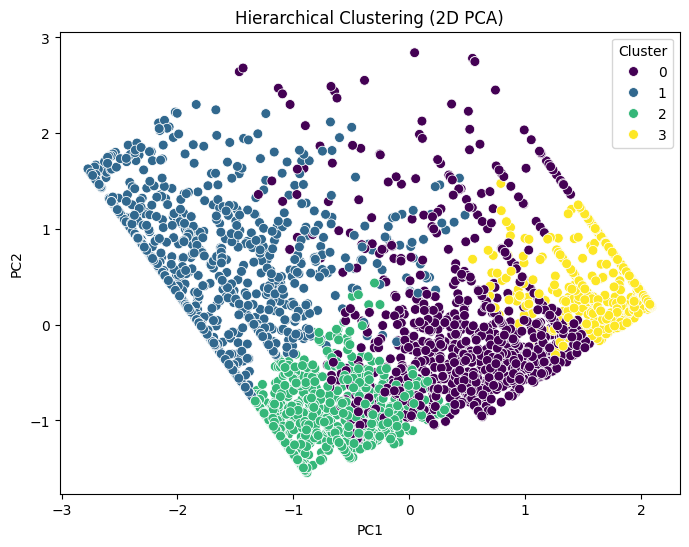

In [11]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca_2d[:, 0],
    y=X_pca_2d[:, 1],
    hue=df['HC_Cluster'],
    palette='viridis',
    s=50
)

plt.title('Hierarchical Clustering (2D PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

In [13]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['HC_Cluster'])

print("Silhouette Score (Hierarchical):", score)

Silhouette Score (Hierarchical): 0.3935586290376058


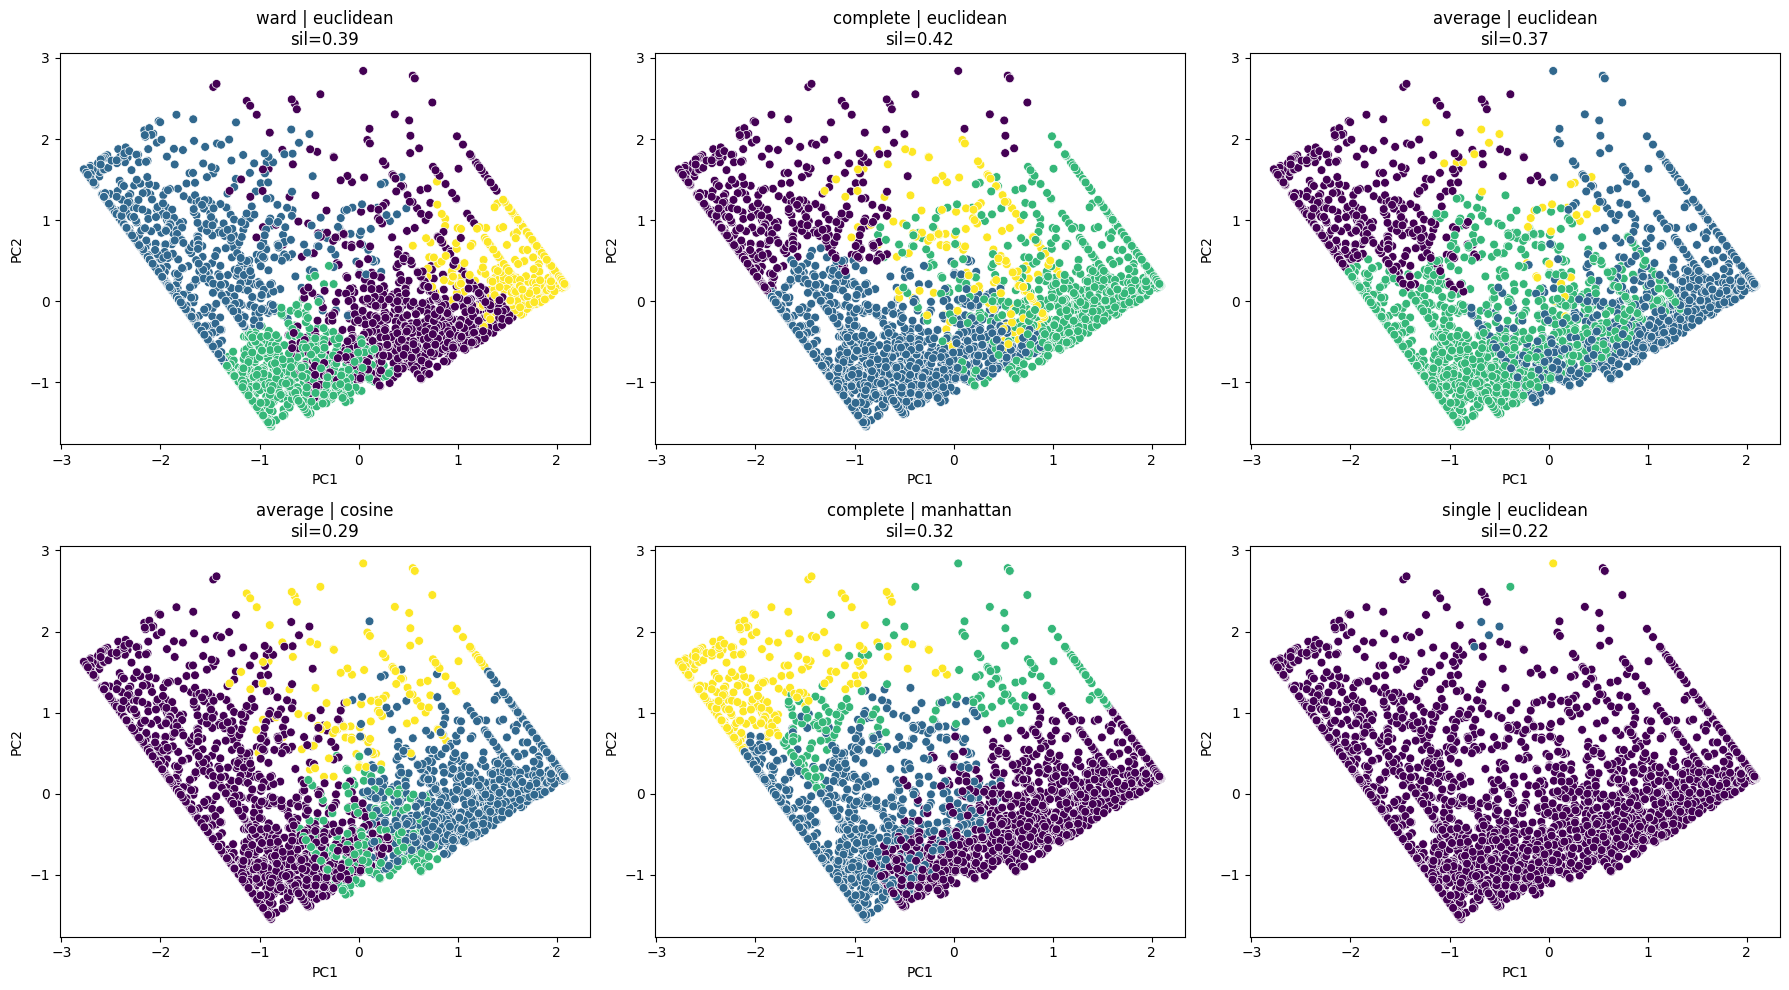

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


X = df[['TOTAL_SPENDING', 'FREQUENCY', 'Recency']]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


linkages = [
    ("ward", "euclidean"),
    ("complete", "euclidean"),
    ("average", "euclidean"),
    ("average", "cosine"),
    ("complete", "manhattan"),
    ("single", "euclidean"),
]

k = 4  

plt.figure(figsize=(18, 10))

for i, (link, metric) in enumerate(linkages, 1):
    
    if link == "ward":
        model = AgglomerativeClustering(n_clusters=k, linkage=link)
    else:
        model = AgglomerativeClustering(n_clusters=k, linkage=link, metric=metric)
    
    labels = model.fit_predict(X_scaled)
    
    
    sil = silhouette_score(X_scaled, labels)
    
    
    plt.subplot(2, 3, i)
    sns.scatterplot(
        x=X_pca[:, 0], y=X_pca[:, 1],
        hue=labels, palette='viridis', legend=False, s=40
    )
    plt.title(f"{link} | {metric}\nsil={sil:.2f}")
    plt.xlabel("PC1"); plt.ylabel("PC2")

plt.tight_layout()
plt.show()